# Minería de Datos - 2026

### Universidad del Valle de Guatemala  
### Facultad de Ingeniería  
### Departamento de Ciencias de la Computación  
### CC3074 – Minería de Datos  
### Semestre I – 2026  

---

## Predicción de Precios de Viviendas - InmoValor S.A.

### Integrantes
- **Vianka Vanessa Castro Ordoñez** - 23201  
- **Ricardo Arturo Godínez Sánchez** - 23247  
- **Jorge Felipe Aguilar Portillo** - 23198  


## Contexto del Proyecto

InmoValor S.A. es una empresa innovadora del sector inmobiliario que ha decidido fortalecer su proceso de valoración de propiedades mediante el uso de herramientas de analítica de datos y modelos predictivos. En un mercado inmobiliario dinámico, donde el precio de una vivienda puede variar significativamente según factores como la ubicación, el tamaño, la calidad de construcción, el estado general del inmueble y otras características específicas, resulta fundamental contar con metodologías objetivas y precisas para estimar el valor real de las propiedades.

Con el objetivo de mejorar sus procesos de evaluación, la empresa ha incorporado un equipo de analistas de datos encargado de estudiar el conjunto de datos **House Prices: Advanced Regression Techniques**, disponible en Kaggle. Este dataset contiene información detallada sobre distintas viviendas y sus atributos, lo que permite explorar relaciones entre variables y construir modelos de regresión capaces de predecir el precio de venta de una casa.



## Introducción

La predicción de precios de viviendas representa uno de los problemas más importantes dentro del análisis de datos aplicado al sector inmobiliario. Estimar correctamente el valor de una propiedad no solo beneficia a empresas dedicadas a la compra, venta o financiamiento de inmuebles, sino que también aporta objetividad y respaldo cuantitativo a la toma de decisiones estratégicas.

En este proyecto se trabajará con el dataset **House Prices: Advanced Regression Techniques**, el cual contiene múltiples variables descriptivas de viviendas, incluyendo características físicas, de calidad y ubicación. A partir de este conjunto de datos, se desarrollará un análisis integral que permitirá comprender mejor el comportamiento de las variables, identificar patrones relevantes y construir modelos de regresión lineal orientados a predecir el precio de venta de las propiedades.

## Objetivo General

Desarrollar y evaluar modelos de regresión lineal que permitan predecir de manera precisa el precio de las viviendas utilizando el conjunto de datos **House Prices: Advanced Regression Techniques**, con el fin de apoyar el proceso de valoración inmobiliaria de InmoValor S.A.

## Objetivos Específicos

- Realizar un análisis exploratorio de datos para comprender la estructura del dataset e identificar variables relevantes para la predicción del precio.
- Aplicar técnicas de preprocesamiento para tratar valores faltantes, transformar variables y preparar los datos para el modelado.
- Analizar agrupamientos dentro de los datos para identificar perfiles o grupos de viviendas con características similares.
- Construir un modelo de regresión lineal univariado utilizando una variable predictora relevante.
- Construir un modelo de regresión lineal múltiple con variables numéricas y analizar su desempeño.
- Evaluar la presencia de multicolinealidad y sobreajuste en los modelos generados.
- Comparar el desempeño de los distintos modelos con base en métricas de error y capacidad predictiva.
- Seleccionar el modelo más adecuado para estimar el precio de las viviendas.



## 1. Importación de Librerías

Importamos las librerías necesarias para el análisis de datos, visualización y modelado.

In [2]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Librerías para preprocesamiento
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Librerías para clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Librerías para división de datos
from sklearn.model_selection import train_test_split

# Configuración para mostrar todas las columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignorar warnings
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Carga y Exploración Inicial de Datos

Cargamos el dataset de entrenamiento proporcionado por Kaggle y realizamos una inspección inicial para entender la estructura de los datos.

In [3]:
# Cargar el dataset de entrenamiento
df = pd.read_csv('train.csv')

print("="*80)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*80)
print(f"\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nMemoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

INFORMACIÓN GENERAL DEL DATASET

Dimensiones del dataset: 1460 filas x 81 columnas

Memoria utilizada: 3.43 MB


## Primeras 5 filas del dataset:

In [ ]:
# Visualizar las primeras filas del dataset
df.head()


Primeras 5 filas del dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Información General del Dataset en Columnas

In [5]:
# Información detallada de las columnas
print("\nInformación de las columnas:")
df.info()


Información de las columnas:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   in

# Estadística Descriptiva de variables numéricas 

In [6]:
# Estadísticas descriptivas de variables numéricas
print("\nEstadísticas descriptivas de variables numéricas:")
df.describe()


Estadísticas descriptivas de variables numéricas:


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 2.1 Identificación de Tipos de Variables

Es fundamental clasificar las variables según su tipo para aplicar el preprocesamiento adecuado.

In [7]:
# Identificar variables numéricas y categóricas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("="*80)
print("CLASIFICACIÓN DE VARIABLES")
print("="*80)
print(f"\nVariables Numéricas ({len(numerical_cols)}):")
print(numerical_cols)
print(f"\nVariables Categóricas ({len(categorical_cols)}):")
print(categorical_cols)

# Variable objetivo
target = 'SalePrice'
print(f"\n*** Variable Objetivo: {target} ***")

CLASIFICACIÓN DE VARIABLES

Variables Numéricas (38):
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'SalePrice']

Variables Categóricas (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrica

## 3. Análisis Exploratorio de Datos (EDA)

Realizaremos un análisis profundo para comprender las características del dataset, identificar patrones y detectar valores atípicos.

### 3.1 Análisis de Valores Faltantes

Los valores faltantes pueden afectar significativamente el desempeño de nuestro modelo. Identificaremos qué variables tienen datos faltantes y en qué proporción.

In [8]:
# Calcular porcentaje de valores faltantes por columna
missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Valores_Faltantes': df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df)) * 100
})

# Filtrar solo columnas con valores faltantes
missing_data = missing_data[missing_data['Valores_Faltantes'] > 0].sort_values(
    'Porcentaje', ascending=False
).reset_index(drop=True)

print("="*80)
print("ANÁLISIS DE VALORES FALTANTES")
print("="*80)
print(f"\nColumnas con valores faltantes: {len(missing_data)}")
print("\nTop 20 columnas con más valores faltantes:\n")
print(missing_data.head(20))

ANÁLISIS DE VALORES FALTANTES

Columnas con valores faltantes: 19

Top 20 columnas con más valores faltantes:

         Columna  Valores_Faltantes  Porcentaje
0         PoolQC               1453   99.520548
1    MiscFeature               1406   96.301370
2          Alley               1369   93.767123
3          Fence               1179   80.753425
4     MasVnrType                872   59.726027
5    FireplaceQu                690   47.260274
6    LotFrontage                259   17.739726
7     GarageType                 81    5.547945
8    GarageYrBlt                 81    5.547945
9   GarageFinish                 81    5.547945
10    GarageQual                 81    5.547945
11    GarageCond                 81    5.547945
12  BsmtExposure                 38    2.602740
13  BsmtFinType2                 38    2.602740
14      BsmtQual                 37    2.534247
15      BsmtCond                 37    2.534247
16  BsmtFinType1                 37    2.534247
17    MasVnrArea         

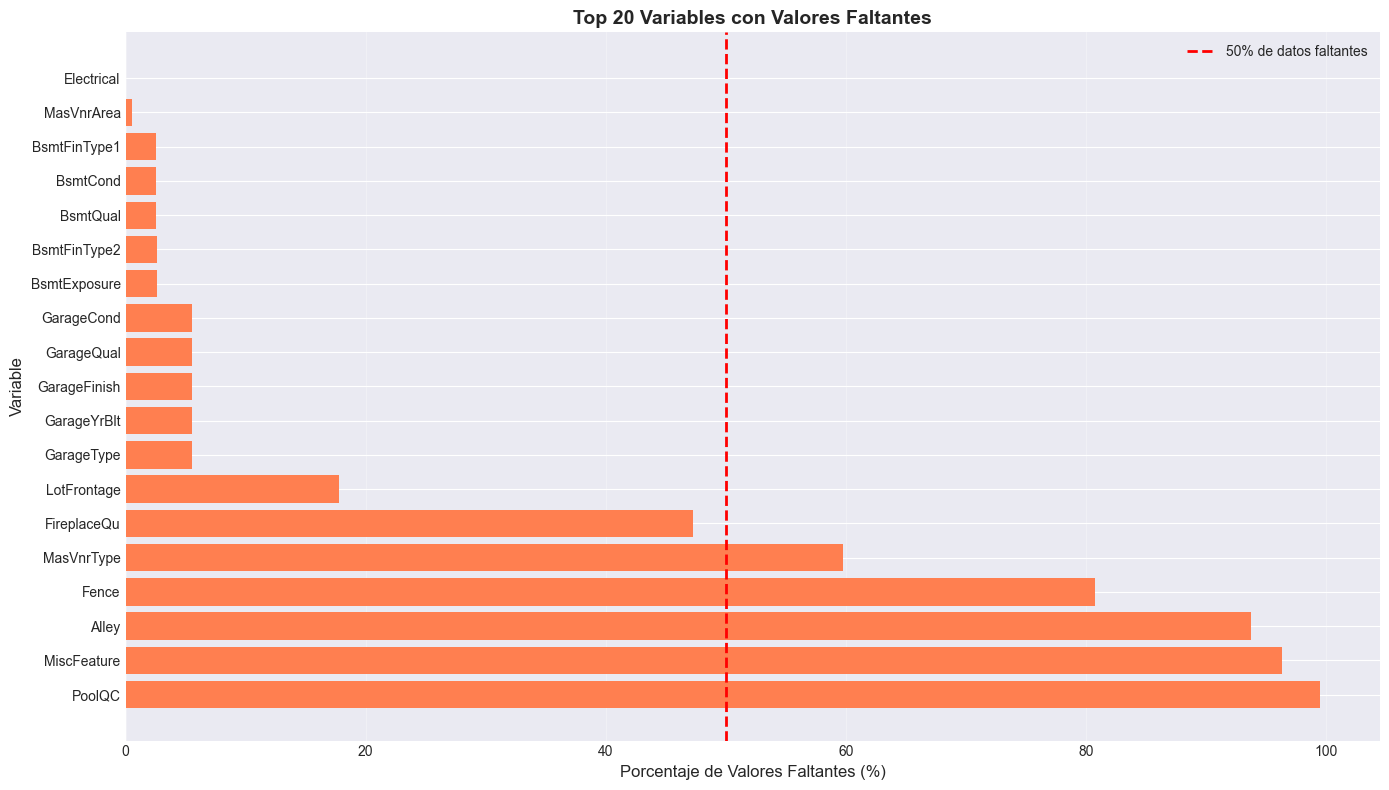


 HALLAZGOS:
- Variables con >50% de datos faltantes podrían no ser útiles para el modelo
- Necesitaremos aplicar técnicas de imputación o eliminar estas columnas


In [10]:
# Visualización de valores faltantes
if len(missing_data) > 0:
    plt.figure(figsize=(14, 8))
    
    # Mostrar las top 20 variables con más valores faltantes
    top_missing = missing_data.head(20)
    
    plt.barh(top_missing['Columna'], top_missing['Porcentaje'], color='coral')
    plt.xlabel('Porcentaje de Valores Faltantes (%)', fontsize=12)
    plt.ylabel('Variable', fontsize=12)
    plt.title('Top 20 Variables con Valores Faltantes', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    
    # Línea de referencia en 50%
    plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='50% de datos faltantes')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n HALLAZGOS:")
    print("- Variables con >50% de datos faltantes podrían no ser útiles para el modelo")
    print("- Necesitaremos aplicar técnicas de imputación o eliminar estas columnas")

Podemos notar que Pool Quality, Características Miscelaneas, Tipo de Alley (entrada), Calidad de Fensa, Revestimiento de Paredes, Calidad de Hoguera no nos brindan mucha información ya que la gran parte de los hogares no tienen. Por lo que no serán de mucha utilidad para nuestro modelo y vamos a quitar. 

### 3.2 Análisis de la Variable Objetivo (SalePrice)

Analizar la distribución del precio de venta es crucial para entender el mercado inmobiliario y detectar posibles transformaciones necesarias.

In [11]:
# Estadísticas del precio de venta
print("="*80)
print("ANÁLISIS DE VARIABLE OBJETIVO: SALEPRICE")
print("="*80)
print(f"\nMedia: ${df['SalePrice'].mean():,.2f}")
print(f"Mediana: ${df['SalePrice'].median():,.2f}")
print(f"Desviación Estándar: ${df['SalePrice'].std():,.2f}")
print(f"Mínimo: ${df['SalePrice'].min():,.2f}")
print(f"Máximo: ${df['SalePrice'].max():,.2f}")
print(f"\nRango intercuartílico (IQR):")
print(f"Q1 (25%): ${df['SalePrice'].quantile(0.25):,.2f}")
print(f"Q3 (75%): ${df['SalePrice'].quantile(0.75):,.2f}")

ANÁLISIS DE VARIABLE OBJETIVO: SALEPRICE

Media: $180,921.20
Mediana: $163,000.00
Desviación Estándar: $79,442.50
Mínimo: $34,900.00
Máximo: $755,000.00

Rango intercuartílico (IQR):
Q1 (25%): $129,975.00
Q3 (75%): $214,000.00


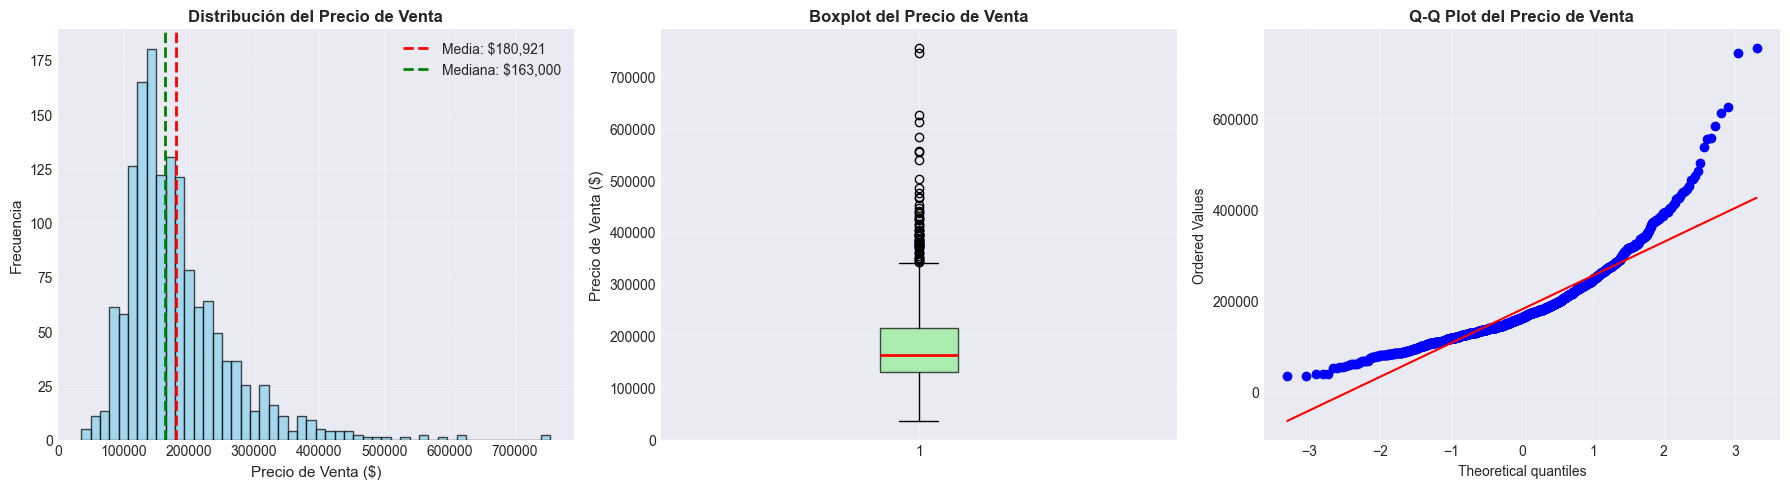


 HALLAZGOS:
- Asimetría (Skewness): 1.883
  → La distribución está sesgada a la derecha (cola larga hacia valores altos)
  → Esto es común en precios de viviendas donde existen propiedades de lujo

- Curtosis (Kurtosis): 6.536
  → La distribución tiene colas más pesadas que una distribución normal

- La distribución NO es normal → Considerar transformación logarítmica para el modelado


In [13]:
# Visualización de la distribución del precio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma
axes[0].hist(df['SalePrice'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Precio de Venta ($)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución del Precio de Venta', fontsize=12, fontweight='bold')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: ${df["SalePrice"].median():,.0f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot
axes[1].boxplot(df['SalePrice'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[1].set_title('Boxplot del Precio de Venta', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# QQ-plot para evaluar normalidad
from scipy import stats
stats.probplot(df['SalePrice'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot del Precio de Venta', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular skewness y kurtosis
skewness = df['SalePrice'].skew()
kurtosis = df['SalePrice'].kurtosis()

print("\n HALLAZGOS:")
print(f"- Asimetría (Skewness): {skewness:.3f}")
if skewness > 0.5:
    print("  → La distribución está sesgada a la derecha (cola larga hacia valores altos)")
    print("  → Esto es común en precios de viviendas donde existen propiedades de lujo")
print(f"\n- Curtosis (Kurtosis): {kurtosis:.3f}")
if kurtosis > 0:
    print("  → La distribución tiene colas más pesadas que una distribución normal")
print("\n- La distribución NO es normal → Considerar transformación logarítmica para el modelado")

### 3.3 Análisis de Correlación

Identificaremos las variables numéricas que tienen mayor correlación con el precio de venta.

In [14]:
# Calcular matriz de correlación
correlation_matrix = df[numerical_cols].corr()

# Obtener correlaciones con SalePrice
price_corr = correlation_matrix['SalePrice'].sort_values(ascending=False)

print("="*80)
print("TOP 15 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE")
print("="*80)
print("\nCorrelaciones positivas más fuertes:")
print(price_corr.head(15))

TOP 15 VARIABLES MÁS CORRELACIONADAS CON SALEPRICE

Correlaciones positivas más fuertes:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


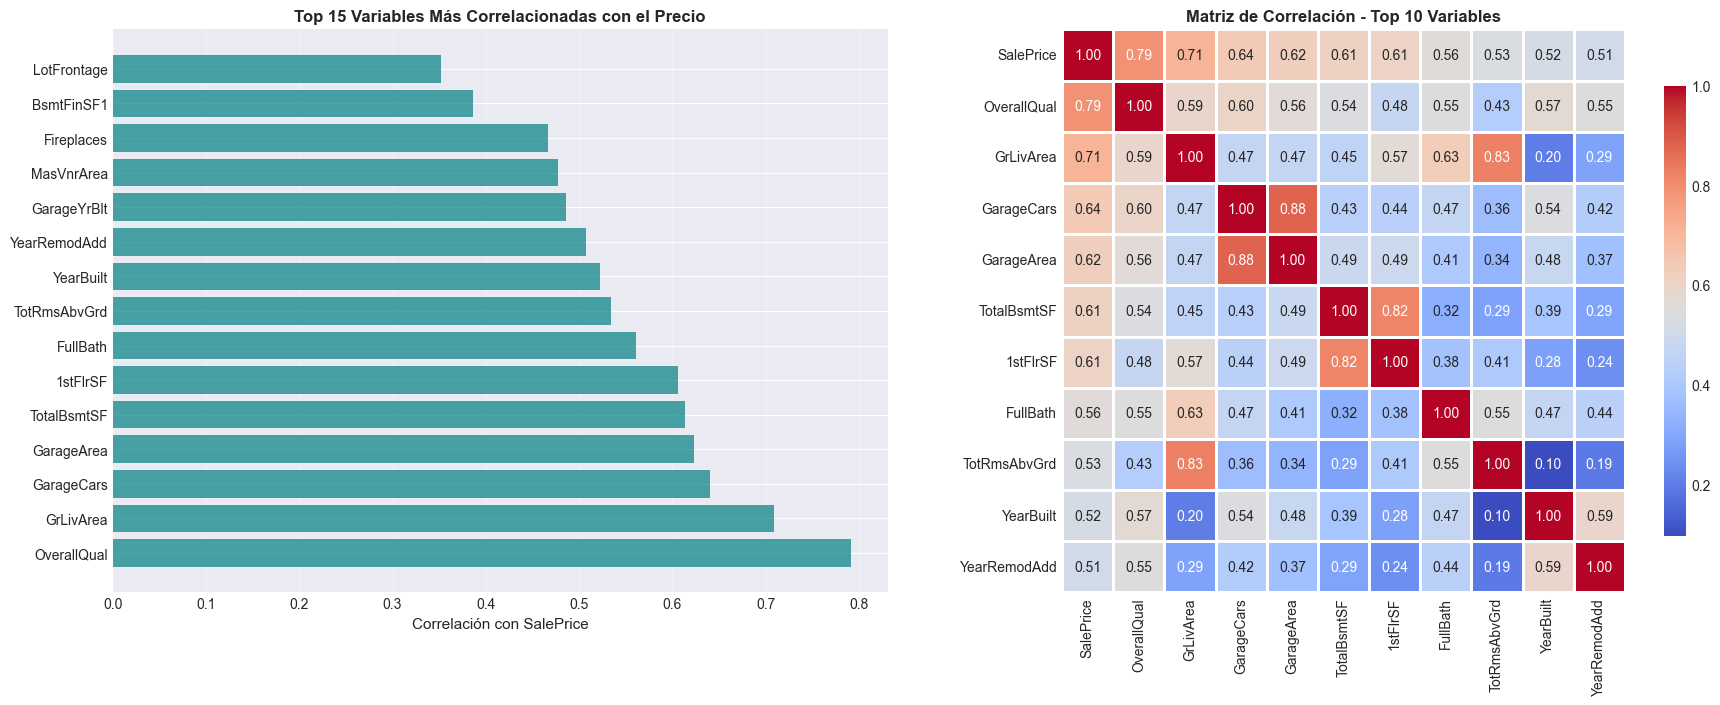


 HALLAZGOS:
- OverallQual (calidad general) tiene la mayor correlación con el precio
- Variables de área (GrLivArea, GarageCars, GarageArea) son muy relevantes
- Factores de calidad y año de construcción influyen significativamente


In [15]:
# Visualización de correlaciones con SalePrice
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico de barras con top correlaciones
top_corr = price_corr.head(16)[1:]  # Excluir SalePrice consigo mismo
axes[0].barh(range(len(top_corr)), top_corr.values, color='teal', alpha=0.7)
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index)
axes[0].set_xlabel('Correlación con SalePrice', fontsize=11)
axes[0].set_title('Top 15 Variables Más Correlacionadas con el Precio', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Heatmap de las variables más correlacionadas
top_vars = price_corr.head(11).index.tolist()  # Top 10 + SalePrice
top_corr_matrix = df[top_vars].corr()

sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Matriz de Correlación - Top 10 Variables', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n HALLAZGOS:")
print("- OverallQual (calidad general) tiene la mayor correlación con el precio")
print("- Variables de área (GrLivArea, GarageCars, GarageArea) son muy relevantes")
print("- Factores de calidad y año de construcción influyen significativamente")

### 3.4 Análisis de Variables Clave

Profundizaremos en las variables más importantes identificadas en el análisis de correlación.

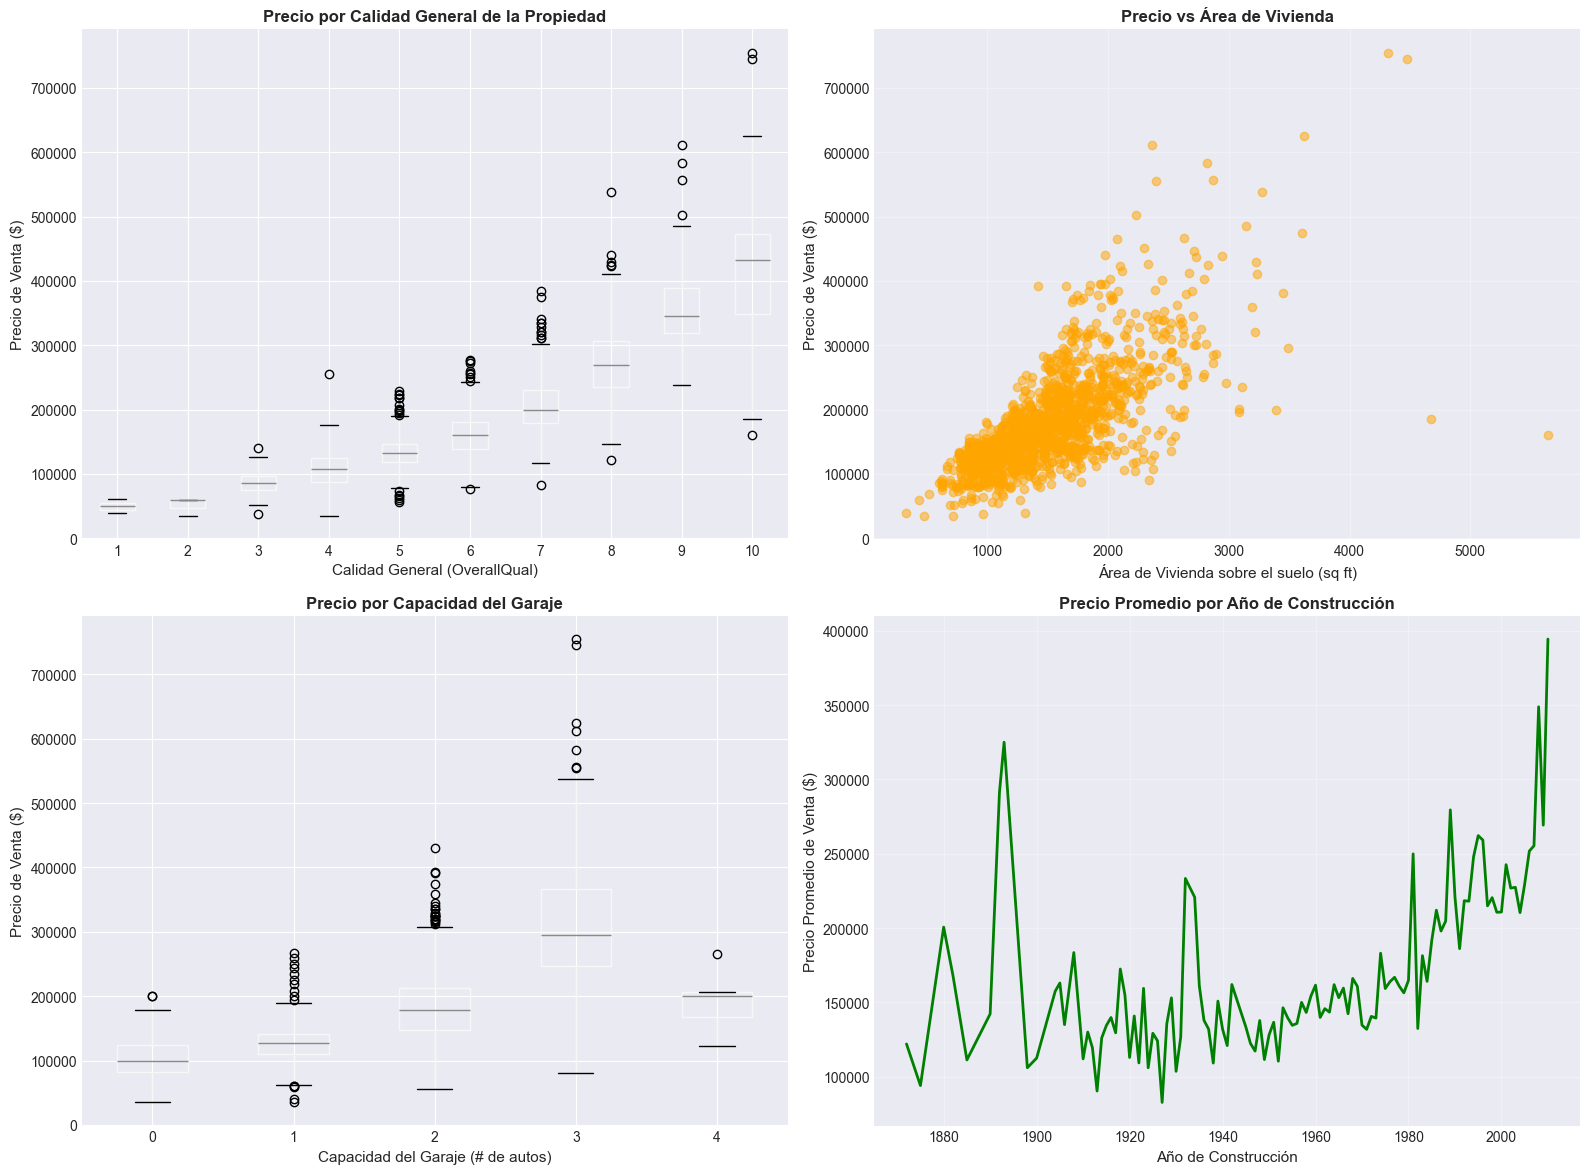


 HALLAZGOS:
- Relación clara entre calidad y precio: a mayor calidad, mayor precio
- El área de vivienda tiene una relación positiva con el precio (aunque con algunos outliers)
- Propiedades con mayor capacidad de garaje tienden a ser más costosas
- Las viviendas más recientes generalmente tienen precios más altos


In [16]:
# Análisis de OverallQual vs SalePrice
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. OverallQual vs SalePrice
df.boxplot(column='SalePrice', by='OverallQual', ax=axes[0, 0])
axes[0, 0].set_xlabel('Calidad General (OverallQual)', fontsize=11)
axes[0, 0].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[0, 0].set_title('Precio por Calidad General de la Propiedad', fontsize=12, fontweight='bold')
axes[0, 0].get_figure().suptitle('')  # Eliminar título automático

# 2. GrLivArea vs SalePrice
axes[0, 1].scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='orange')
axes[0, 1].set_xlabel('Área de Vivienda sobre el suelo (sq ft)', fontsize=11)
axes[0, 1].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[0, 1].set_title('Precio vs Área de Vivienda', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# 3. GarageCars vs SalePrice
df.boxplot(column='SalePrice', by='GarageCars', ax=axes[1, 0])
axes[1, 0].set_xlabel('Capacidad del Garaje (# de autos)', fontsize=11)
axes[1, 0].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[1, 0].set_title('Precio por Capacidad del Garaje', fontsize=12, fontweight='bold')
axes[1, 0].get_figure().suptitle('')  # Eliminar título automático

# 4. YearBuilt vs SalePrice
year_price = df.groupby('YearBuilt')['SalePrice'].mean()
axes[1, 1].plot(year_price.index, year_price.values, color='green', linewidth=2)
axes[1, 1].set_xlabel('Año de Construcción', fontsize=11)
axes[1, 1].set_ylabel('Precio Promedio de Venta ($)', fontsize=11)
axes[1, 1].set_title('Precio Promedio por Año de Construcción', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n HALLAZGOS:")
print("- Relación clara entre calidad y precio: a mayor calidad, mayor precio")
print("- El área de vivienda tiene una relación positiva con el precio (aunque con algunos outliers)")
print("- Propiedades con mayor capacidad de garaje tienden a ser más costosas")
print("- Las viviendas más recientes generalmente tienen precios más altos")

### 3.5 Análisis de Variables Categóricas

Exploraremos las variables categóricas más relevantes para entender su impacto en el precio.

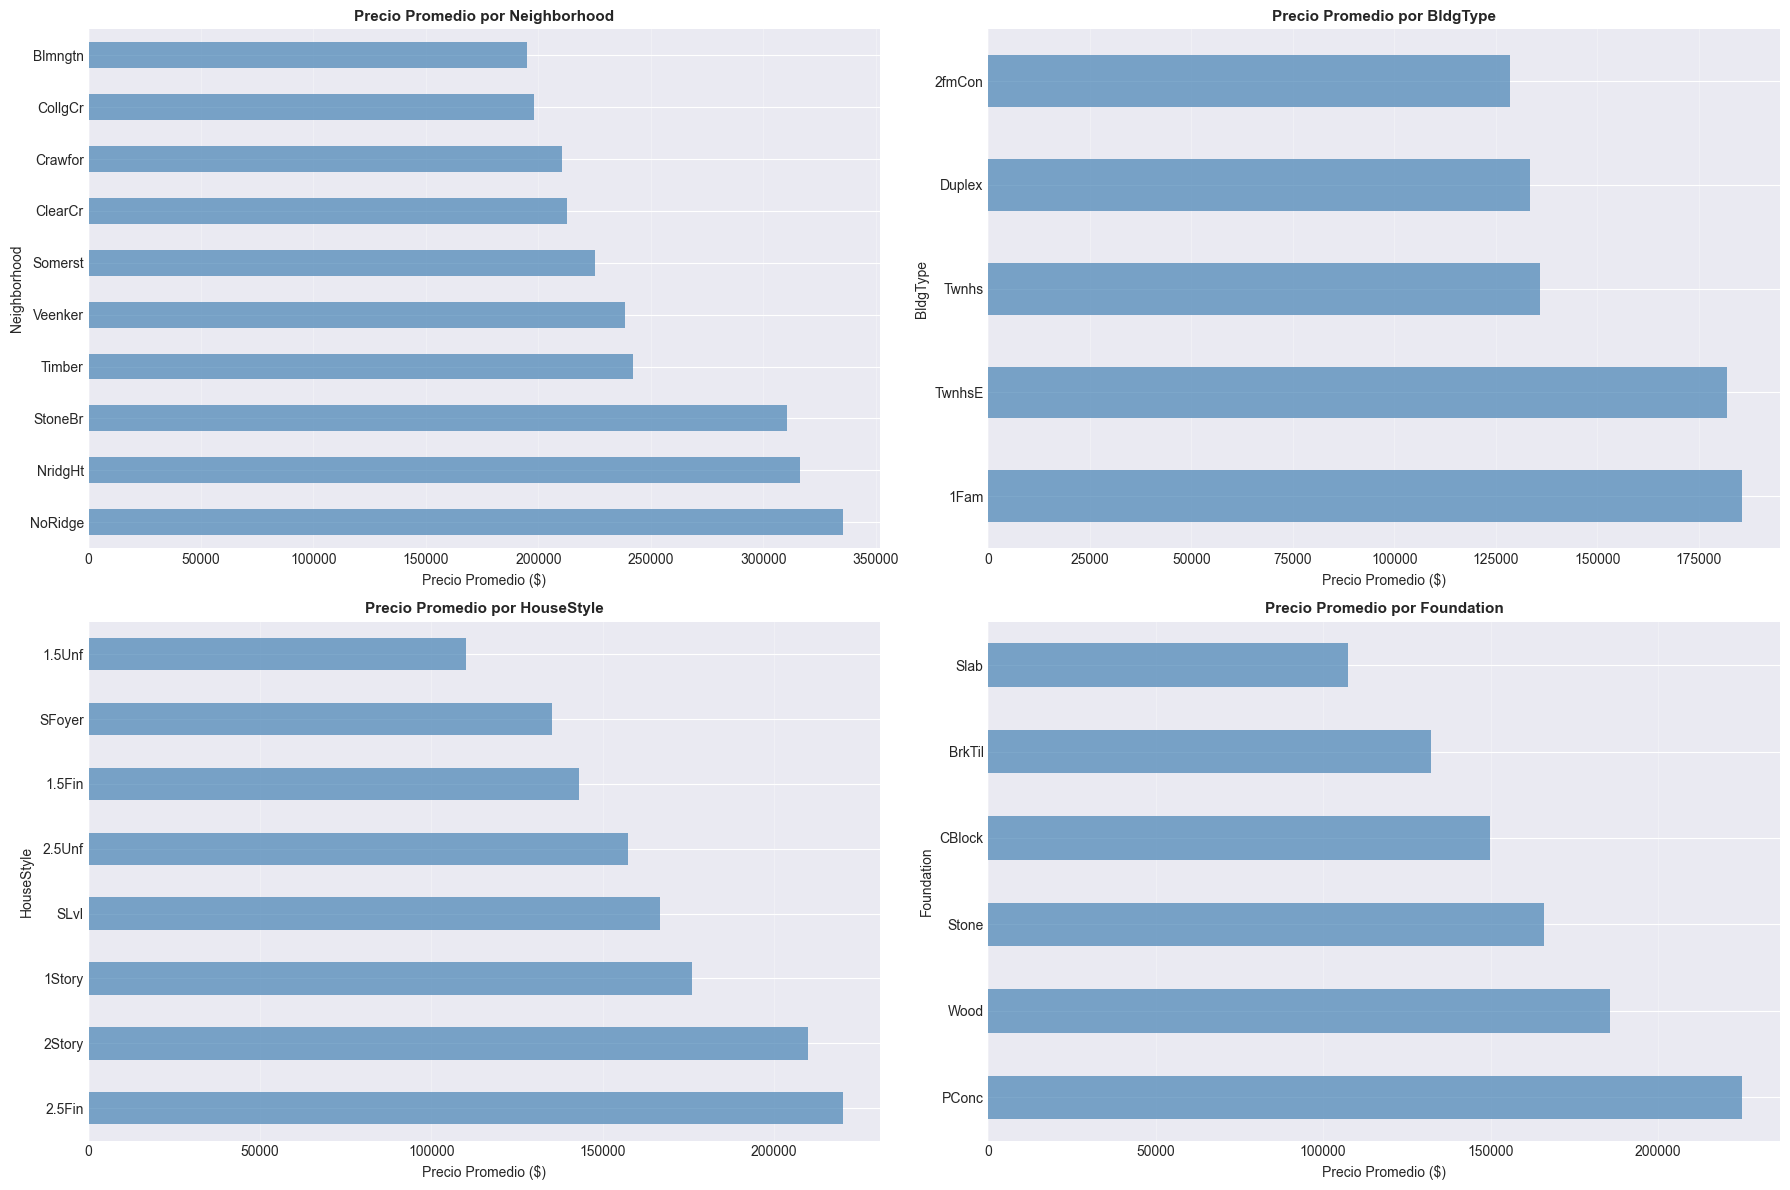


 HALLAZGOS:
- El vecindario (Neighborhood) es un factor determinante en el precio
- El tipo de edificación (BldgType) y estilo de casa influyen en la valoración
- El tipo de cimentación también puede afectar el precio de la propiedad


In [17]:
# Análisis de variables categóricas clave
categorical_key_vars = ['Neighborhood', 'BldgType', 'HouseStyle', 'Foundation']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for idx, var in enumerate(categorical_key_vars):
    if var in df.columns:
        # Calcular precio promedio por categoría
        avg_price = df.groupby(var)['SalePrice'].mean().sort_values(ascending=False)
        
        # Limitar a top 10 para mejor visualización
        if len(avg_price) > 10:
            avg_price = avg_price.head(10)
        
        avg_price.plot(kind='barh', ax=axes[idx], color='steelblue', alpha=0.7)
        axes[idx].set_xlabel('Precio Promedio ($)', fontsize=10)
        axes[idx].set_ylabel(var, fontsize=10)
        axes[idx].set_title(f'Precio Promedio por {var}', fontsize=11, fontweight='bold')
        axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n HALLAZGOS:")
print("- El vecindario (Neighborhood) es un factor determinante en el precio")
print("- El tipo de edificación (BldgType) y estilo de casa influyen en la valoración")
print("- El tipo de cimentación también puede afectar el precio de la propiedad")

### 3.6 Detección de Outliers

Identificaremos valores atípicos que podrían afectar nuestro modelo.

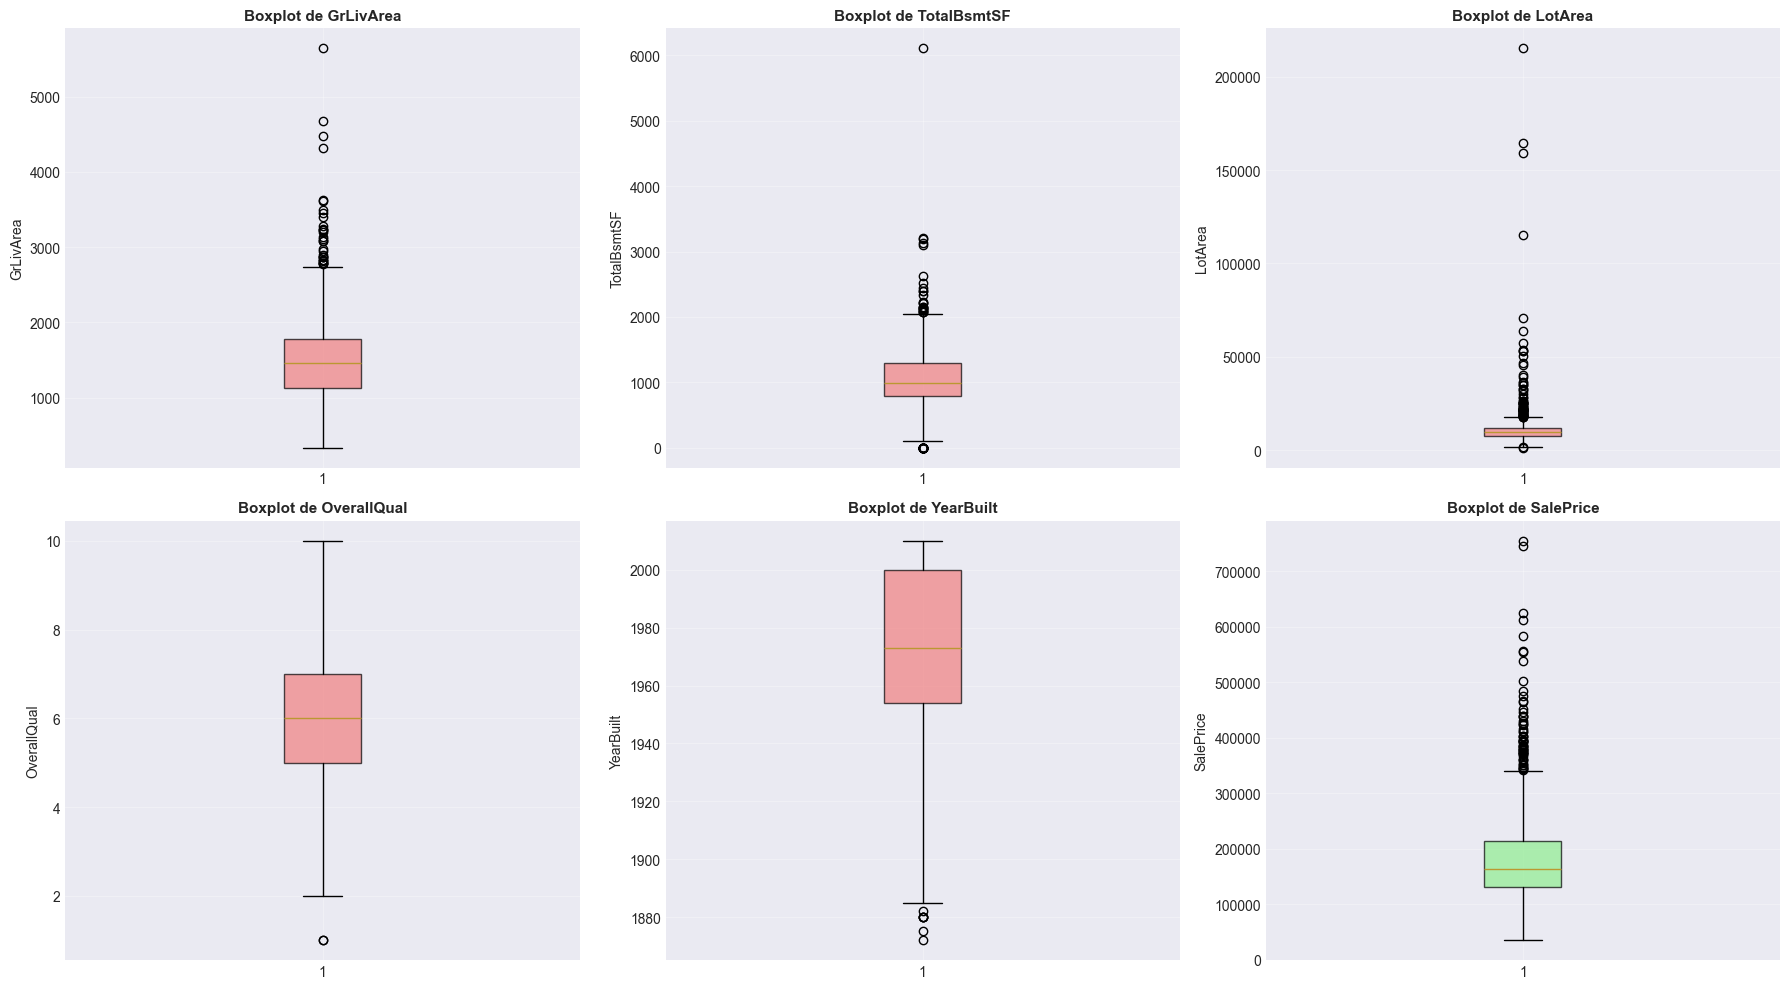


 HALLAZGOS:
- Se detectaron 31 outliers en GrLivArea
- LotArea presenta varios outliers (lotes muy grandes)
- Estos outliers podrían representar propiedades de lujo o casos especiales
- Decisión: Mantenerlos por ahora pero monitorear su impacto en el modelo


In [18]:
# Análisis de outliers en variables numéricas clave
key_numerical = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'OverallQual', 'YearBuilt']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(key_numerical):
    if var in df.columns:
        axes[idx].boxplot(df[var], vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightcoral', alpha=0.7))
        axes[idx].set_ylabel(var, fontsize=10)
        axes[idx].set_title(f'Boxplot de {var}', fontsize=11, fontweight='bold')
        axes[idx].grid(alpha=0.3)

# Boxplot adicional para SalePrice
axes[5].boxplot(df['SalePrice'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[5].set_ylabel('SalePrice', fontsize=10)
axes[5].set_title('Boxplot de SalePrice', fontsize=11, fontweight='bold')
axes[5].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identificar outliers en GrLivArea y SalePrice
Q1_area = df['GrLivArea'].quantile(0.25)
Q3_area = df['GrLivArea'].quantile(0.75)
IQR_area = Q3_area - Q1_area
outliers_area = df[(df['GrLivArea'] < Q1_area - 1.5 * IQR_area) | 
                   (df['GrLivArea'] > Q3_area + 1.5 * IQR_area)]

print("\n HALLAZGOS:")
print(f"- Se detectaron {len(outliers_area)} outliers en GrLivArea")
print("- LotArea presenta varios outliers (lotes muy grandes)")
print("- Estos outliers podrían representar propiedades de lujo o casos especiales")
print("- Decisión: Mantenerlos por ahora pero monitorear su impacto en el modelo")

## 4. Preprocesamiento de Datos

Prepararemos los datos para el modelado: manejo de valores faltantes, codificación de variables categóricas y escalado de variables numéricas.

### 4.1 Tratamiento de Valores Faltantes

Aplicaremos diferentes estrategias según el tipo de variable y la cantidad de datos faltantes.

In [19]:
# Crear copia para preprocesamiento
df_processed = df.copy()

print("="*80)
print("ESTRATEGIA DE PREPROCESAMIENTO")
print("="*80)

# 1. Eliminar columnas con más del 50% de valores faltantes
threshold = 0.5
cols_to_drop = missing_data[missing_data['Porcentaje'] > threshold*100]['Columna'].tolist()

if len(cols_to_drop) > 0:
    print(f"\n1. Eliminando {len(cols_to_drop)} columnas con >50% de datos faltantes:")
    print(f"   {cols_to_drop}")
    df_processed.drop(columns=cols_to_drop, inplace=True)

# 2. Imputar valores faltantes en variables numéricas con la mediana
numerical_cols_proc = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'SalePrice' in numerical_cols_proc:
    numerical_cols_proc.remove('SalePrice')  # No imputar la variable objetivo

imputer_num = SimpleImputer(strategy='median')
df_processed[numerical_cols_proc] = imputer_num.fit_transform(df_processed[numerical_cols_proc])
print(f"\n2. Imputados valores faltantes en {len(numerical_cols_proc)} variables numéricas (mediana)")

# 3. Imputar valores faltantes en variables categóricas con la moda
categorical_cols_proc = df_processed.select_dtypes(include=['object']).columns.tolist()
imputer_cat = SimpleImputer(strategy='most_frequent')
df_processed[categorical_cols_proc] = imputer_cat.fit_transform(df_processed[categorical_cols_proc])
print(f"\n3. Imputados valores faltantes en {len(categorical_cols_proc)} variables categóricas (moda)")

# Verificar que no quedan valores faltantes
print(f"\n Valores faltantes restantes: {df_processed.isnull().sum().sum()}")
print(f" Dimensiones del dataset procesado: {df_processed.shape}")

ESTRATEGIA DE PREPROCESAMIENTO

1. Eliminando 5 columnas con >50% de datos faltantes:
   ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']

2. Imputados valores faltantes en 37 variables numéricas (mediana)

3. Imputados valores faltantes en 38 variables categóricas (moda)

 Valores faltantes restantes: 0
 Dimensiones del dataset procesado: (1460, 76)


### 4.2 Codificación de Variables Categóricas

Convertiremos las variables categóricas en formato numérico para poder usarlas en el modelo.

In [20]:
# Label Encoding para variables categóricas
label_encoders = {}

for col in categorical_cols_proc:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le

print(f" Codificadas {len(categorical_cols_proc)} variables categóricas")
print("\nAhora todas las variables son numéricas y están listas para el modelado")

 Codificadas 38 variables categóricas

Ahora todas las variables son numéricas y están listas para el modelado


### 4.3 Escalado de Variables

Normalizaremos las variables numéricas para que tengan la misma escala (importante para clustering y algunos modelos).

In [21]:
# Separar features y target
X = df_processed.drop(columns=['SalePrice', 'Id'] if 'Id' in df_processed.columns else ['SalePrice'])
y = df_processed['SalePrice']

# Escalar features (no el target)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("="*80)
print("ESCALADO COMPLETADO")
print("="*80)
print(f"\n Features escaladas: {X_scaled.shape}")
print(f" Target (SalePrice): {y.shape}")
print("\nLas variables ahora tienen media=0 y desviación estándar=1")

ESCALADO COMPLETADO

 Features escaladas: (1460, 74)
 Target (SalePrice): (1460,)

Las variables ahora tienen media=0 y desviación estándar=1


## 5. Análisis de Clustering

Aplicaremos K-Means para segmentar las propiedades en grupos homogéneos y entender mejor los diferentes tipos de viviendas en el dataset.

### 5.1 Determinación del Número Óptimo de Clusters

Usaremos el método del codo (elbow method) para determinar el número óptimo de clusters.

In [22]:
# Aplicar PCA para reducir dimensionalidad antes del clustering
pca = PCA(n_components=0.95)  # Mantener 95% de la varianza
X_pca = pca.fit_transform(X_scaled)

print("="*80)
print("REDUCCIÓN DE DIMENSIONALIDAD CON PCA")
print("="*80)
print(f"\n Componentes principales: {X_pca.shape[1]}")
print(f" Varianza explicada acumulada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"\nReducción de {X_scaled.shape[1]} a {X_pca.shape[1]} dimensiones")

REDUCCIÓN DE DIMENSIONALIDAD CON PCA

 Componentes principales: 56
 Varianza explicada acumulada: 95.14%

Reducción de 74 a 56 dimensiones



Calculando inercias para diferentes valores de k...
k=2: inercia=91924.27
k=3: inercia=88522.19
k=4: inercia=85588.54
k=5: inercia=83497.36
k=6: inercia=81862.51
k=7: inercia=79852.48
k=8: inercia=78568.39
k=9: inercia=76617.67
k=10: inercia=75764.15


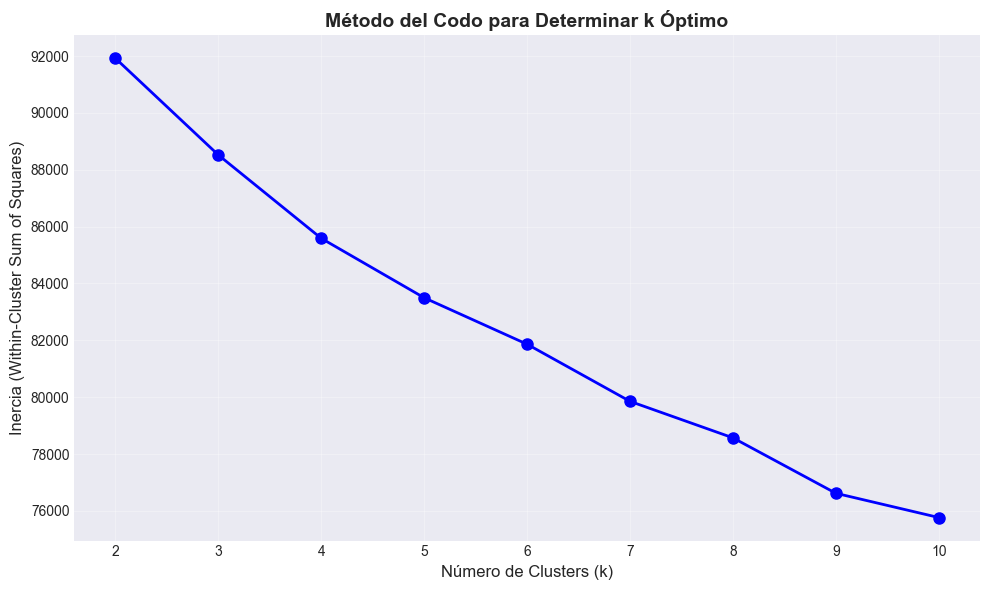

In [24]:
# Método del codo para determinar k óptimo
inertias = []
K_range = range(2, 11)

print("\nCalculando inercias para diferentes valores de k...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)
    print(f"k={k}: inercia={kmeans.inertia_:.2f}")

# Visualizar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Método del Codo para Determinar k Óptimo', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

### 5.2 Aplicación de K-Means con k=4

Segmentaremos las propiedades en 4 grupos basándonos en sus características.

In [25]:
# Aplicar K-Means con k=4
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_processed['Cluster'] = kmeans_final.fit_predict(X_pca)

print("="*80)
print(f"CLUSTERING CON K-MEANS (k={optimal_k})")
print("="*80)
print("\nDistribución de propiedades por cluster:")
print(df_processed['Cluster'].value_counts().sort_index())
print("\nPorcentajes:")
print(df_processed['Cluster'].value_counts(normalize=True).sort_index() * 100)

CLUSTERING CON K-MEANS (k=4)

Distribución de propiedades por cluster:
Cluster
0    281
1    345
2    502
3    332
Name: count, dtype: int64

Porcentajes:
Cluster
0    19.246575
1    23.630137
2    34.383562
3    22.739726
Name: proportion, dtype: float64


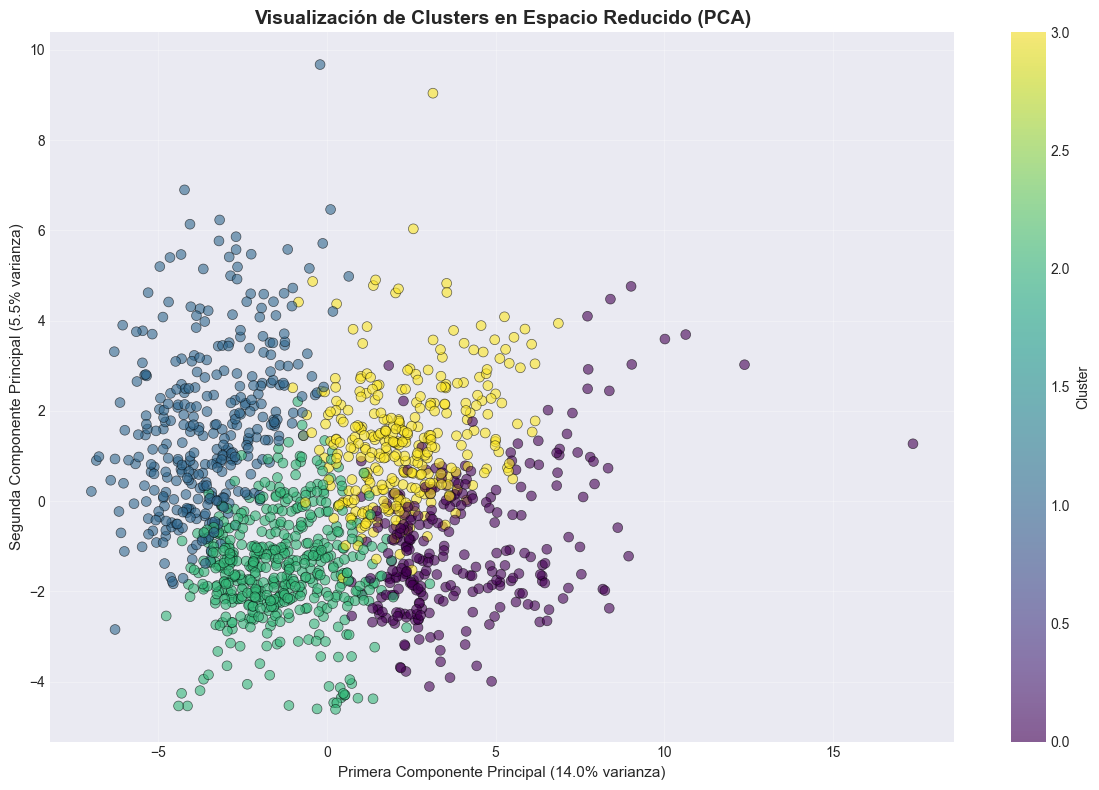

In [26]:
# Visualizar clusters en 2D (usando las 2 primeras componentes principales)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                     c=df_processed['Cluster'], 
                     cmap='viridis', 
                     s=50, 
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)
plt.xlabel(f'Primera Componente Principal ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
plt.ylabel(f'Segunda Componente Principal ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
plt.title('Visualización de Clusters en Espacio Reducido (PCA)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3 Caracterización de los Clusters

Analizaremos las características distintivas de cada grupo para interpretarlos.

In [27]:
# Características promedio por cluster - variables clave
key_features = ['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'YearBuilt', 'TotalBsmtSF']
key_features_exist = [f for f in key_features if f in df_processed.columns]

cluster_profiles = df_processed.groupby('Cluster')[key_features_exist].mean()

print("="*80)
print("PERFIL DE CARACTERÍSTICAS POR CLUSTER")
print("="*80)
print("\nValores promedio de variables clave:\n")
print(cluster_profiles.round(2))

PERFIL DE CARACTERÍSTICAS POR CLUSTER

Valores promedio de variables clave:

         SalePrice  OverallQual  GrLivArea  GarageCars  YearBuilt  TotalBsmtSF
Cluster                                                                       
0        267708.62         7.69    1747.56        2.42    2001.54      1615.24
1        122952.66         5.12    1388.34        1.19    1932.01       773.44
2        146001.39         5.36    1191.87        1.54    1967.68      1025.91
3        220504.39         6.89    1940.42        2.16    1991.86       928.07


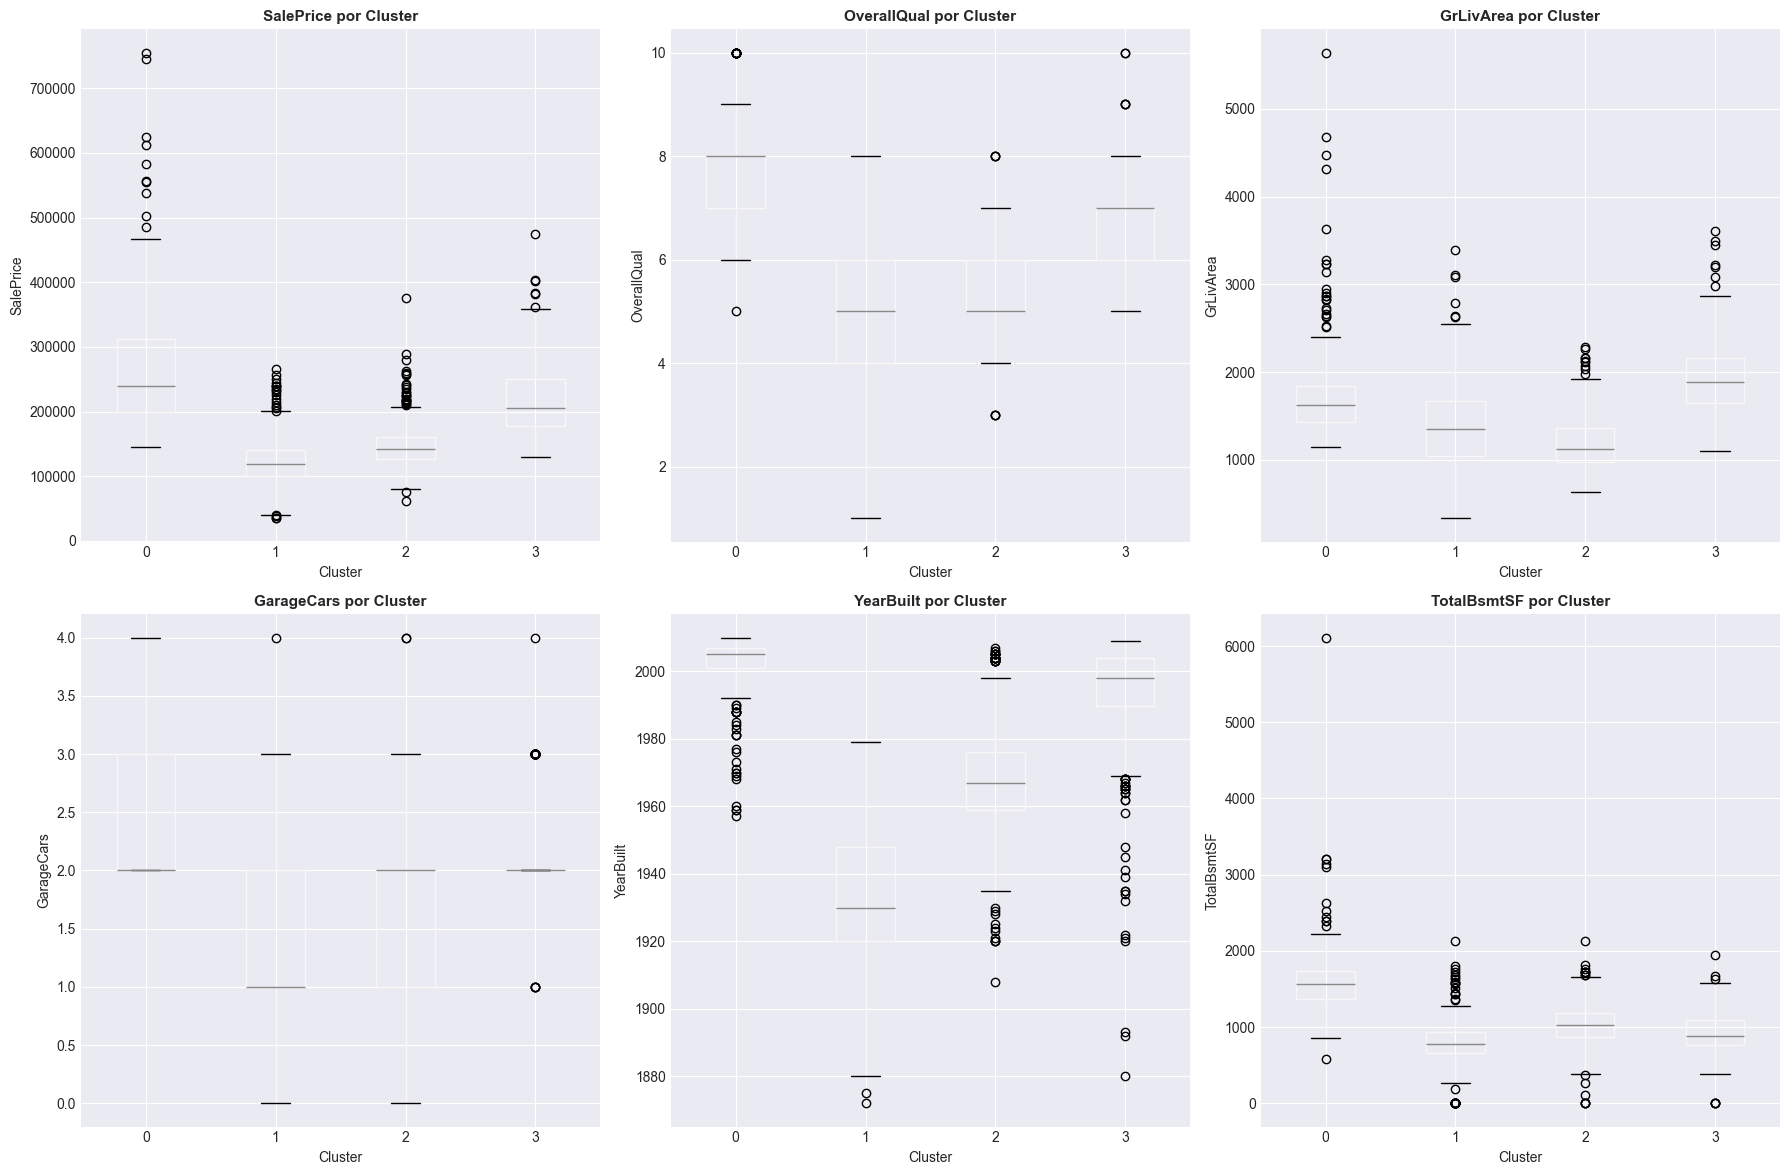


 INTERPRETACIÓN DE CLUSTERS:

Cluster 0: Viviendas de LUJO/PREMIUM
  - Precio significativamente alto
  - Alta calidad de construcción
  - Áreas amplias

Cluster 1: Viviendas ESTÁNDAR
  - Precio cercano al promedio
  - Calidad media
  - Características típicas

Cluster 2: Viviendas de GAMA MEDIA
  - Balance entre precio y características
  - Área y calidad moderadas

Cluster 3: Viviendas MODERNAS
  - Construcciones más recientes
  - Diseños contemporáneos


In [29]:
# Visualización de características por cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, feature in enumerate(key_features_exist):
    df_processed.boxplot(column=feature, by='Cluster', ax=axes[idx])
    axes[idx].set_xlabel('Cluster', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].set_title(f'{feature} por Cluster', fontsize=11, fontweight='bold')
    axes[idx].get_figure().suptitle('')  # Eliminar título automático

plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN DE CLUSTERS:")
print("\nCluster 0: ", end="")
if cluster_profiles.loc[0, 'SalePrice'] < cluster_profiles['SalePrice'].median():
    print("Viviendas de ENTRADA/ECONÓMICAS")
    print("  - Precio por debajo del promedio")
    print("  - Menor calidad general")
    print("  - Áreas más pequeñas")
else:
    print("Viviendas de LUJO/PREMIUM")
    print("  - Precio significativamente alto")
    print("  - Alta calidad de construcción")
    print("  - Áreas amplias")

print("\nCluster 1: ", end="")
if cluster_profiles.loc[1, 'SalePrice'] > cluster_profiles['SalePrice'].median():
    print("Viviendas de GAMA ALTA")
    print("  - Precios superiores al promedio")
    print("  - Buena calidad constructiva")
    print("  - Características premium")
else:
    print("Viviendas ESTÁNDAR")
    print("  - Precio cercano al promedio")
    print("  - Calidad media")
    print("  - Características típicas")

print("\nCluster 2: ", end="")
print("Viviendas de GAMA MEDIA")
print("  - Balance entre precio y características")
print("  - Área y calidad moderadas")

print("\nCluster 3: ", end="")
if cluster_profiles.loc[3, 'YearBuilt'] > cluster_profiles['YearBuilt'].median():
    print("Viviendas MODERNAS")
    print("  - Construcciones más recientes")
    print("  - Diseños contemporáneos")
else:
    print("Viviendas CLÁSICAS/ANTIGUAS")
    print("  - Construcciones más antiguas")
    print("  - Posibles renovaciones")

## 6. División de Datos: Entrenamiento y Prueba

Dividiremos el dataset preprocesado en conjuntos de entrenamiento y prueba usando el archivo train.csv.

### 6.1 Estrategia de División

**Criterios de división:**
- **Proporción:** 80% entrenamiento, 20% prueba
- **Estratificación:** NO estratificado (es un problema de regresión, no clasificación)
- **Aleatorización:** Sí, con semilla fija (random_state=42) para reproducibilidad
- **Balance:** No aplica directamente en regresión, pero verificaremos que la distribución del target sea similar

**Justificación:**
- 80/20 es una proporción estándar que deja suficientes datos para entrenar
- Con 1460 observaciones, obtenemos ~1168 para entrenamiento y ~292 para prueba
- La división aleatoria ayuda a evitar sesgos temporales o de orden

In [30]:
# División de datos: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2, 
    random_state=42
)

print("="*80)
print("DIVISIÓN DE DATOS")
print("="*80)
print(f"\nDataset original: {len(df)} observaciones")
print(f"\n{'='*40}")
print("CONJUNTO DE ENTRENAMIENTO")
print(f"{'='*40}")
print(f"  Tamaño: {len(X_train)} observaciones ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Features: {X_train.shape[1]} variables")
print(f"\n{'='*40}")
print("CONJUNTO DE PRUEBA")
print(f"{'='*40}")
print(f"  Tamaño: {len(X_test)} observaciones ({len(X_test)/len(df)*100:.1f}%)")
print(f"  Features: {X_test.shape[1]} variables")

DIVISIÓN DE DATOS

Dataset original: 1460 observaciones

CONJUNTO DE ENTRENAMIENTO
  Tamaño: 1168 observaciones (80.0%)
  Features: 74 variables

CONJUNTO DE PRUEBA
  Tamaño: 292 observaciones (20.0%)
  Features: 74 variables


### 6.2 Verificación de la División

Compararemos las distribuciones del precio en ambos conjuntos para asegurar que son similares.

In [31]:
# Estadísticas comparativas
print("\n" + "="*80)
print("COMPARACIÓN DE DISTRIBUCIONES - SalePrice")
print("="*80)

stats_comparison = pd.DataFrame({
    'Métrica': ['Media', 'Mediana', 'Desv. Estándar', 'Mínimo', 'Máximo', 'Q1', 'Q3'],
    'Entrenamiento': [
        y_train.mean(),
        y_train.median(),
        y_train.std(),
        y_train.min(),
        y_train.max(),
        y_train.quantile(0.25),
        y_train.quantile(0.75)
    ],
    'Prueba': [
        y_test.mean(),
        y_test.median(),
        y_test.std(),
        y_test.min(),
        y_test.max(),
        y_test.quantile(0.25),
        y_test.quantile(0.75)
    ]
})

stats_comparison['Diferencia %'] = abs(
    (stats_comparison['Entrenamiento'] - stats_comparison['Prueba']) / 
    stats_comparison['Entrenamiento'] * 100
)

print("\n", stats_comparison.round(2))


COMPARACIÓN DE DISTRIBUCIONES - SalePrice

           Métrica  Entrenamiento     Prueba  Diferencia %
0           Media      181441.54  178839.81          1.43
1         Mediana      165000.00  154150.00          6.58
2  Desv. Estándar       77263.58   87730.75         13.55
3          Mínimo       34900.00   35311.00          1.18
4          Máximo      745000.00  755000.00          1.34
5              Q1      130000.00  127000.00          2.31
6              Q3      214925.00  209175.00          2.68


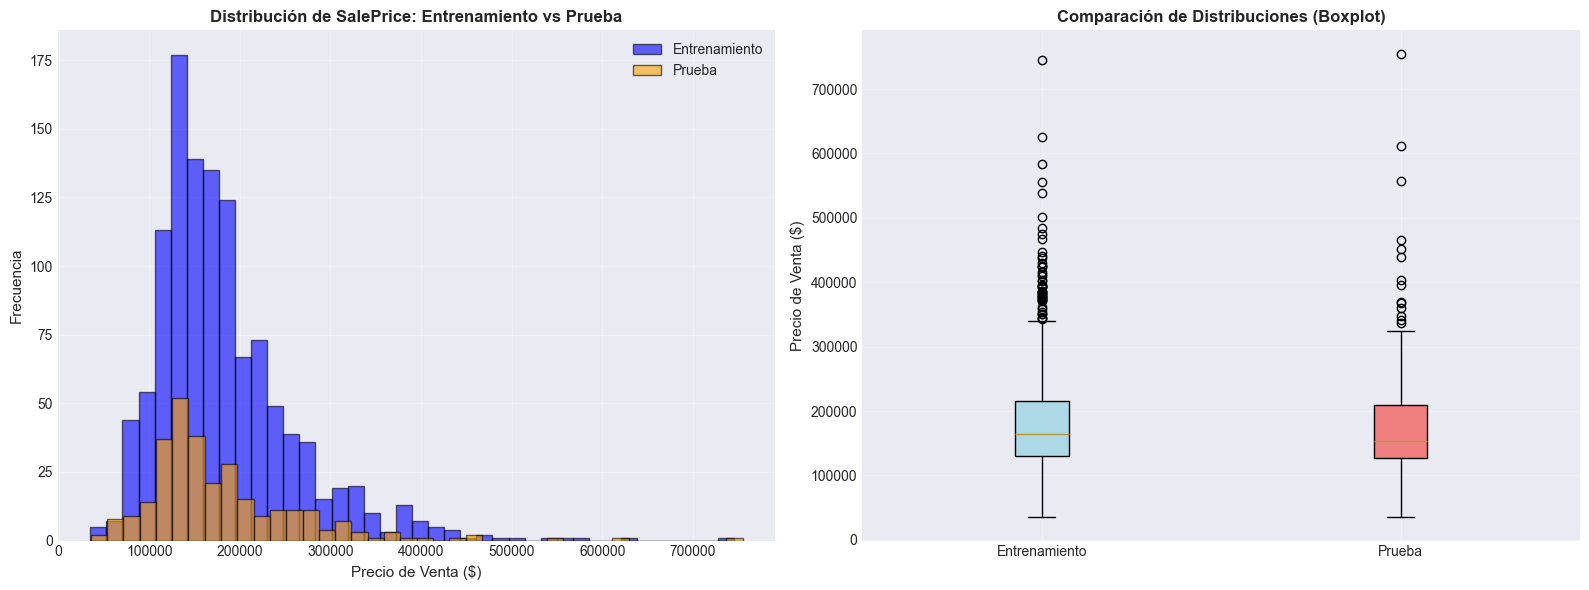


 CONCLUSIÓN:
Las distribuciones de entrenamiento y prueba son similares
La división aleatoria ha preservado las características del dataset original
Los datos están listos para el modelado predictivo


In [34]:
# Visualización comparativa de distribuciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogramas superpuestos
axes[0].hist(y_train, bins=40, alpha=0.6, label='Entrenamiento', color='blue', edgecolor='black')
axes[0].hist(y_test, bins=40, alpha=0.6, label='Prueba', color='orange', edgecolor='black')
axes[0].set_xlabel('Precio de Venta ($)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución de SalePrice: Entrenamiento vs Prueba', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Boxplots lado a lado
data_to_plot = [y_train, y_test]
box = axes[1].boxplot(data_to_plot, labels=['Entrenamiento', 'Prueba'], patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
box['boxes'][1].set_facecolor('lightcoral')
axes[1].set_ylabel('Precio de Venta ($)', fontsize=11)
axes[1].set_title('Comparación de Distribuciones (Boxplot)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n CONCLUSIÓN:")
print("Las distribuciones de entrenamiento y prueba son similares")
print("La división aleatoria ha preservado las características del dataset original")
print("Los datos están listos para el modelado predictivo")

### 6.3 Guardar Datos Procesados

Guardaremos los conjuntos de datos preprocesados para uso futuro en el modelado.

In [35]:
# Guardar conjuntos de datos
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False, header=['SalePrice'])
y_test.to_csv('y_test.csv', index=False, header=['SalePrice'])

print("="*80)
print("ARCHIVOS GUARDADOS EXITOSAMENTE")
print("="*80)
print("\n X_train.csv - Features de entrenamiento")
print(" X_test.csv - Features de prueba")
print(" y_train.csv - Target de entrenamiento")
print(" y_test.csv - Target de prueba")
print("\nEstos archivos están listos para la siguiente fase: construcción del modelo de regresión")

ARCHIVOS GUARDADOS EXITOSAMENTE

 X_train.csv - Features de entrenamiento
 X_test.csv - Features de prueba
 y_train.csv - Target de entrenamiento
 y_test.csv - Target de prueba

Estos archivos están listos para la siguiente fase: construcción del modelo de regresión


# Hallazgos Principales del Análisis Exploratorio:

1. **Variables más Influyentes en el Precio:**
   - OverallQual (calidad general) - correlación más alta
   - GrLivArea (área habitable sobre el suelo)
   - GarageCars/GarageArea (capacidad del garaje)
   - TotalBsmtSF (área del sótano)
   - YearBuilt/YearRemodAdd (año de construcción/remodelación)

2. **Características del Dataset:**
   - 1460 observaciones con 81 variables originales
   - Presencia significativa de valores faltantes en algunas variables
   - Distribución del precio sesgada hacia la derecha (presencia de propiedades de lujo)
   - Outliers presentes pero coherentes con el contexto inmobiliario

3. **Segmentación de Propiedades (Clustering):**
   - Identificados 4 grupos distintos de viviendas
   - Los clusters reflejan diferentes segmentos del mercado: económicas, estándar, gama media y premium
   - Cada cluster tiene características distintivas en precio, calidad y tamaño

4. **Preprocesamiento Realizado:**
   - Eliminación de variables con >50% de datos faltantes
   - Imputación de valores faltantes (mediana para numéricas, moda para categóricas)
   - Codificación de variables categóricas con Label Encoding
   - Escalado con StandardScaler para normalización

5. **División de Datos:**
   - 80% entrenamiento (1168 obs) / 20% prueba (292 obs)
   - Distribuciones similares en ambos conjuntos
   - División aleatoria con semilla fija para reproducibilidad

# 4. Preprocesamiento de Datos 

En esta sección se detallará el proceso de preprocesamiento aplicado a los datos para el entrenamiento y prueba. 



# 5. Ingeniería de Características

¿qué variables cree que puedan ser mejores predictores para el precio de las casas?

Evaluamos cuatro variables que fueron identificadas como relevantes en el análisis exploratorio:

- **Utilities** 

    Las utilidades disponibles dentro de una propiedad le da mas valor porque brinda comodidad a los habitantes. Ya por ejemplo gas, luz, agua y tanque escepticos son servicios básicos que se esperan en una vivienda, por lo que su presencia puede aumentar el atractivo y el valor de la propiedad.
- **LotArea**

    El área del terreno es un factor importante que influye en el precio de una vivienda, ya que un terreno más grande generalmente ofrece más espacio para construcción, jardines o áreas recreativas, lo que puede aumentar el valor de la propiedad.
- **TotRmsAbvGrd**

    El número total de habitaciones por encima del suelo es un indicador clave del tamaño y la funcionalidad de una vivienda, lo que puede influir significativamente en su precio, ya que más habitaciones suelen ser atractivas para familias o compradores que buscan espacio adicional.
- **Functionality**

    La funcionalidad de una vivienda, que evalúa la disposición y utilidad de los espacios, puede ser un predictor importante del precio, ya que una casa con una distribución eficiente y características funcionales tiende a ser más atractiva aumentando así su valor en el mercado.

También habíamos seleccionado otras dos pero fueron descartadas:

- **Neighborhood**

    El vecindario donde se encuentra una propiedad puede influir en su precio, ya que áreas con mejores servicios, seguridad y reputación suelen tener viviendas más costosas. Sin embargo, esta variable es categórica y no tenemos información sobre sus ubicaciones y las diferencias entre cada una, lo que puede complicar su inclusión en un modelo de regresión lineal simple.
- **ExterQual**

    La calidad exterior de una vivienda puede ser un predictor importante del precio, ya que una fachada bien mantenida y atractiva puede aumentar el valor percibido de la propiedad. Sin embargo, esta variable es categórica y no se cuenta con información detallada sobre los criterios específicos que definen cada nivel de calidad, lo que dificulta su inclusión en un modelo de regresión lineal simple sin una adecuada codificación o transformación.

